# Day 2 — Ridership Trends + Station Frequencies

**Estimated time:** ~3 hours  •  **Sections:** 3

## Learning objectives

- Load a multi-tab Excel workbook and reshape wide data into long
  format — a level up from the single-CSV morning session.
- Plot MARTA's ridership trend since 2019; identify the COVID dip
  and the fall-2023 faregate data-quality anomaly.
- Clean a messy station-level frequency file: fix inconsistent names,
  fill nulls, drop duplicates.
- Identify the two stadium-adjacent rail stations.

## Table of contents

1. [Section 1 — NTD level-up](#section-1) (~50 min)
2. [Section 2 — Ridership trends](#section-2) (~60 min)
3. [Section 3 — Station frequencies](#section-3) (~70 min)

---

## Setup

Run the next cell.


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent

# Data folder locations
RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
CHECKPOINTS = ROOT / 'data' / 'checkpoints'

In [48]:
# Things we know from yesterday
MARTA_NTD_ID = 40022
NTD_FILE = RAW / 'ntd_monthly_ridership.xlsx'

MODE_NAMES = {'HR': 'Heavy Rail', 'MB': 'Bus', 'SR': 'Streetcar',
              'DR': 'Demand Response'}

# Yesterday Recap
We want to get the data we had yesterday and filter it down to just MARTA rail and bus. How would we do this?


In [ ]:
upt_data = pd.read_excel(NTD_FILE, sheet_name='UPT')

marta = upt_data[upt_data[???] == ???]

print(marta)
print(marta.columns)

SyntaxError: invalid syntax (3471764862.py, line 3)

One thing we didn't cover yesterday is that the UPT data is wide, we have columns for each month. It's easier to work with long format data, one row per travel mode and date. To do this, we have metadata columns (NTD ID, Agency, Mode, Mode 3, Reporter type, etc.) and then the month columns.

In [ ]:
meta_cols = [???]

month_cols = [c for c in marta.columns if c not in meta_cols]

marta_long = marta.melt(
    id_vars =['Mode', 'TOS'],
    value_vars=month_cols,
    var_name='month_raw',
    value_name='upt'
)

Ok, so the dates are now stored as strings. We need to convert them to actual dates. How would we do this?

In [46]:
marta_long['date'] = pd.to_datetime(marta_long['month_raw'], format="%m/%Y")
marta_long['upt'] = pd.to_numeric(marta_long['upt'], errors='coerce')
marta_long = marta_long.sort_values(["Mode", "date"]).reset_index(drop=True)
marta_long['mode_name'] = marta_long['Mode'].map(MODE_NAMES)
marta_long = marta_long.rename(columns={'Mode': 'mode',
                                        'TOS': 'type_of_service'})

KeyError: 'Mode'

---
<a id="section-2"></a>
## Section 2 — Ridership trends

Now plot ridership by mode from 2019 to present. You're looking for
three things:

1. The **COVID lockdown dip** in spring 2020.
2. MARTA's **ridership recovery** (or lack of it).
3. A **suspicious rail-ridership drop** 


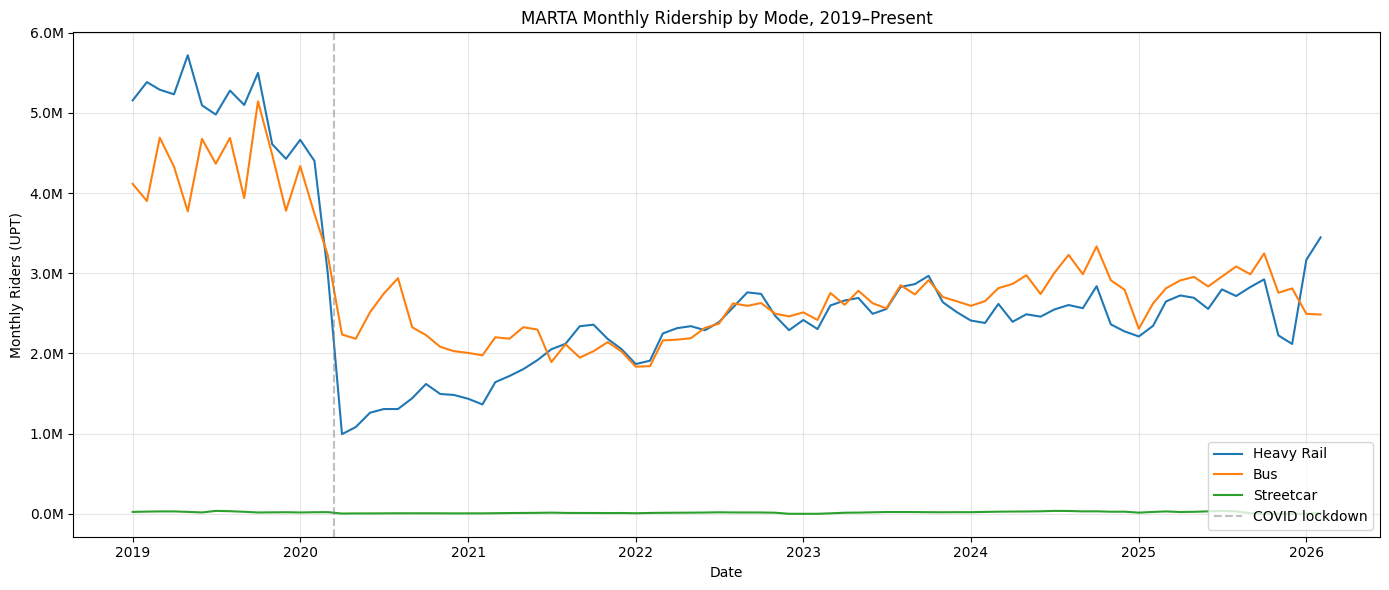

In [43]:
plot_data = marta_long[
    (marta_long['date'] >= '2019-01-01') &
    (marta_long['mode'].isin(['HR', 'MB', 'SR'])) &
    (marta_long['type_of_service'] == 'DO')
].copy()

fig, ax = plt.subplots(figsize=(14, 6))
for mode in ['HR', 'MB', 'SR']:
    d = plot_data[plot_data['mode'] == mode]
    ax.plot(d['date'], d['upt'], label=MODE_NAMES[mode], linewidth=1.5)

ax.axvline(pd.Timestamp('2020-03-15'), color='gray', ls='--', alpha=0.5,
           label='COVID lockdown')

ax.set_xlabel('Date')
ax.set_ylabel('Monthly Riders (UPT)')
ax.set_title('MARTA Monthly Ridership by Mode, 2019–Present')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# Saving this data


In [45]:
marta_long_out = marta_long[['date', 'mode', 'mode_name',
                              'type_of_service', 'upt']]
marta_long_out.to_csv(CHECKPOINTS / 'day2_output_cleaned_ridership.csv',
                       index=False)
print(f'✅ Wrote {len(marta_long_out):,} rows to '
      'data/checkpoints/day2_output_cleaned_ridership.csv')

✅ Wrote 1,740 rows to data/checkpoints/day2_output_cleaned_ridership.csv


## Section 3 — EDA: the three verbs

Three pandas methods solve 80% of exploratory analysis:

- `.describe()` — summary statistics for numeric columns
- `.groupby().agg()` — split-apply-combine (totals by category)
- `.value_counts()` — how many of each label

### 🎯 Exercise 1 — `.describe()` on UPT

What does the distribution of monthly unlinked passenger trips look
like, across every mode and every month in the file? Pick one numeric
column and describe it.


In [ ]:
upt = pd.read_csv(
    CHECKPOINTS / 'day2_output_cleaned_ridership.csv', parse_dates=['date']
)

### 🎯 Exercise 2 — ridership by mode

Group the ridership DataFrame by `mode_name` and compute the **total**
UPT for each mode across the entire time period. Which mode dominates?

<a id="section-4"></a>
## Section 4 — Clean station frequencies, identify stadium stations

In [ ]:
station_frequency = pd.read_csv(PROCESSED / "station_frequency.csv")

### Cleaning recipe

1. **Normalize station names.** Some rows are uppercased. Some have a
   trailing `STATION`. Collapse multiple spaces, strip, title-case.
2. **Drop exact duplicate rows.**
3. **Fill null frequencies** with the median (a reasonable default
   for a small number of missing values).